In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import plotly.express as px

# Load the dataset
df = pd.read_csv("https://raw.githubusercontent.com/mwaskom/seaborn-data/master/tips.csv")

# Display first few rows to verify
df.head()

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4


# Task 1: Distribution Analysis Using Histograms

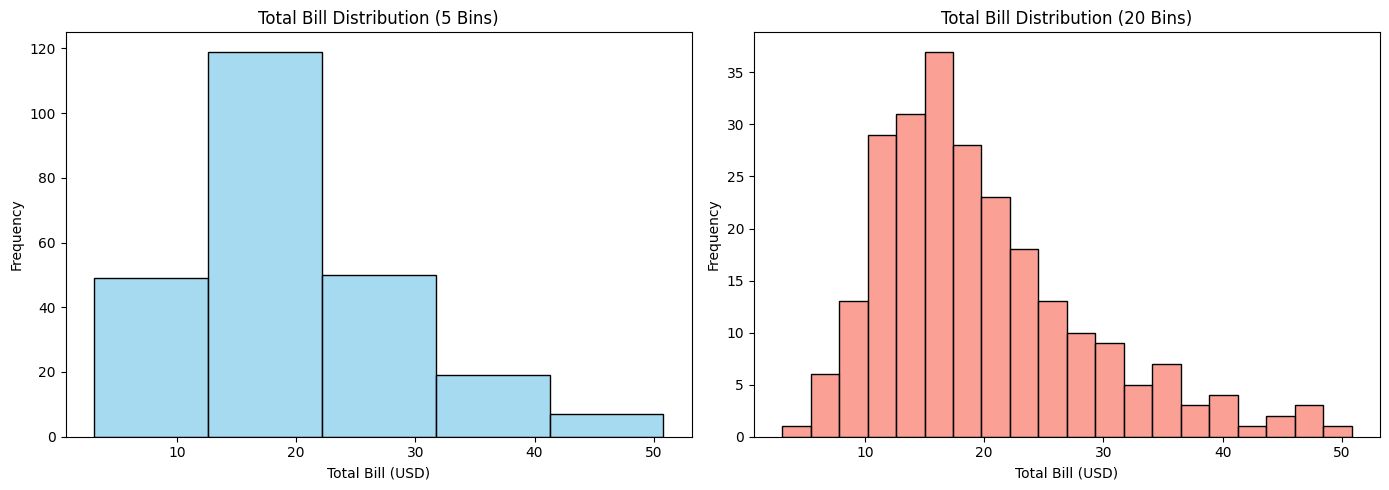

In [2]:
# Create a figure with two subplots
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram 1: 5 Bins
sns.histplot(df['total_bill'], bins=5, color='skyblue', ax=axes[0])
axes[0].set_title('Total Bill Distribution (5 Bins)')
axes[0].set_xlabel('Total Bill (USD)')
axes[0].set_ylabel('Frequency')

# Histogram 2: 20 Bins
sns.histplot(df['total_bill'], bins=20, color='salmon', ax=axes[1])
axes[1].set_title('Total Bill Distribution (20 Bins)')
axes[1].set_xlabel('Total Bill (USD)')
axes[1].set_ylabel('Frequency')

plt.tight_layout()
plt.show()

1.Distribution Shape: The distribution is right-skewed (positively skewed). Most bills are concentrated between $10 and $25, with a long tail extending toward higher bill amounts.

2.Bin Impact: Changing the bin count significantly affects interpretability. With 5 bins, the data is over-summarized, masking smaller fluctuations. With 20 bins, we see more granular detail, such as the specific peak around $15-$20 and gaps in the higher ranges.

# Task 2: Outlier Detection Using Box Plots

/tmp/ipykernel_5634/601220182.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='day', y='total_bill', data=df, palette='Set2')


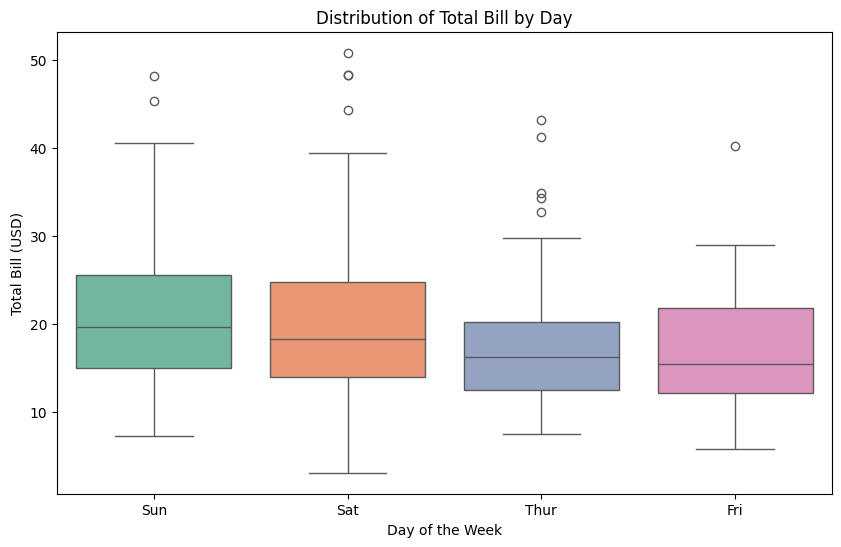

Saturday IQR: 10.84
Lower Bound: -2.35, Upper Bound: 40.99


In [3]:
# Side-by-side box plots
plt.figure(figsize=(10, 6))
sns.boxplot(x='day', y='total_bill', data=df, palette='Set2')
plt.title('Distribution of Total Bill by Day')
plt.xlabel('Day of the Week')
plt.ylabel('Total Bill (USD)')
plt.show()

# Manual IQR Calculation for Saturday (often has many outliers)
sat_data = df[df['day'] == 'Sat']['total_bill']
Q1 = sat_data.quantile(0.25)
Q3 = sat_data.quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

print(f"Saturday IQR: {IQR:.2f}")
print(f"Lower Bound: {lower_bound:.2f}, Upper Bound: {upper_bound:.2f}")

1.Highest Median: Usually, Sunday shows the highest median total bill.
2.Outlier Verification: Saturday and Sunday typically show outliers (points above the top whisker). Using the formula $Q3 + 1.5 \times IQR$, any bill exceeding the calculated Upper Bound is a statistical outlier.

# Task 3: Multi-Variable Comparison (Interactive)

In [4]:
# Interactive Scatter Plot
fig = px.scatter(df, x="total_bill", y="tip", color="time",
                 hover_data=['day', 'size'],
                 title="Relationship between Total Bill and Tip (Colored by Meal Time)")
fig.show()

1.Relationship: There is a positive linear correlation; as the total bill increases, the tip amount generally increases.

2.Meal Time Patterns: Dinner transactions tend to have higher total bills and tips compared to lunch. The color separation shows Lunch (usually smaller bills) clustered at the bottom left, while Dinner dominates the higher-spend area.

3.Unusual Point: (User Choice) Example: "I found a point where the bill was ~$48 but the tip was only ~$5. This is unusual because it falls well below the expected tipping percentage for such a large bill."